In [82]:
from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv
load_dotenv()

True

In [83]:
class structure(BaseModel):
    sentiment:Literal['positive','negative']=Field(description="sentiment of the review")

In [84]:
model= ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [85]:
class review_state(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis:dict
    response:str

In [86]:
def find_sentiment(state:review_state):
    prompt=f"what is the sentiment of the review {state["review"]}"
    sentiment=model.with_structured_output(structure)
    sentiment=sentiment.invoke(prompt).sentiment
    return {"sentiment":sentiment}


In [87]:
class DiagnosisOutput(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')

    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')

    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [88]:
def dignose(state:review_state):
    prompt=f"""
    Diagnose this negative review:\n\n{state['review']}\n
    Return issue_type, tone, and urgency.
    """
    diagnose_model=model.with_structured_output(DiagnosisOutput)
    output=diagnose_model.invoke(prompt)
    return {"diagnosis":output.model_dump()}

In [89]:
def positive_response(state:review_state):
    prompt=f"""
    Write a warm thank-you message in response to this review:\n\n"{state['review']}"\n
    Also, kindly ask the user to leave feedback on our website.
    """
    response=model.invoke(prompt)
    return {"response":response.content}

In [90]:
def negative_response(state:review_state):
    diagnosis=state.get('diagnosis', {})
    prompt=f"""
    You are a support assistant.
    The user had a '{diagnosis.get('issue_type', 'unknown')}' issue, sounded '{diagnosis.get('tone', 'neutral')}', and marked urgency as '{diagnosis.get('urgency', 'medium')}'.
    Write an empathetic, helpful resolution message.
    """
    response=model.invoke(prompt)
    return {"response":response.content}

In [91]:
def conditional_check(state:review_state)->Literal['positive_response','dignose']:
    if state["sentiment"]=="positive":
        return "positive_response"
    else:
        return 'dignose'

In [92]:
graph=StateGraph(review_state)
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)
graph.add_node("dignose",dignose)

In [93]:
graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",conditional_check)
graph.add_edge("dignose","negative_response")
graph.add_edge("negative_response",END)
graph.add_edge("positive_response",END)


In [95]:
workflow=graph.compile()

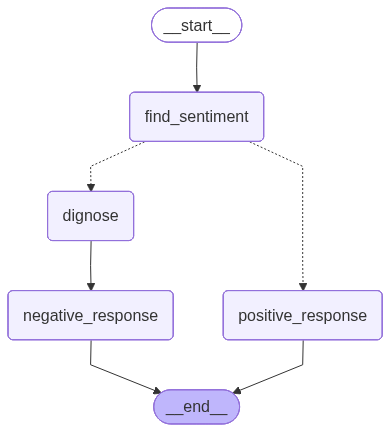

In [96]:
workflow

In [99]:
review =review = """
I contacted customer support three days ago and still have not received any response.
Very disappointed with the service.
"""
intial_input={'review':review}
workflow.invoke(intial_input)

{'review': '\nI contacted customer support three days ago and still have not received any response.\nVery disappointed with the service.\n',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Support',
  'tone': 'disappointed',
  'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a support issue and that it's caused you disappointment. I can imagine how frustrating that must be for you, and I want to assure you that I'm here to help.\n\nI understand that you've marked the urgency as 'high', and I want to assure you that I'll do my best to resolve the issue as quickly as possible. Your satisfaction is my top priority, and I'll work tirelessly to ensure that the problem is fixed to your satisfaction.\n\nTo get started, could you please provide me with more details about the issue you're experiencing? This will help me to better understand the problem and provide a more effective solution. Please know that I'm committed to providing you with the best poss